In [1]:
from langchain.schema import Document
docs = [
    Document(
        page_content=(
            "Bella Vista is owned by Antonio Rossi, a renowned chef with over 20 years of experience "
            "in the culinary industry. He started Bella Vista to bring authentic Italian flavors to the community."
        ),
        metadata={"source": "owner.txt"},
    ),
    Document(
        page_content=(
            "Bella Vista offers a range of dishes with prices that cater to various budgets. "
            "Appetizers start at $8, main courses range from $15 to $35, and desserts are priced between $6 and $12."
        ),
        metadata={"source": "dishes.txt"},
    ),
    Document(
        page_content=(
            "Bella Vista is open from Monday to Sunday. Weekday hours are 11:00 AM to 10:00 PM, "
            "while weekend hours are extended from 11:00 AM to 11:00 PM."
        ),
        metadata={"source": "restaurant_info.txt"},
    ),
    Document(
        page_content=(
            "Bella Vista offers a variety of menus including a lunch menu, dinner menu, and a special weekend brunch menu. "
            "The lunch menu features light Italian fare, the dinner menu offers a more extensive selection of traditional and contemporary dishes, "
            "and the brunch menu includes both classic breakfast items and Italian specialties."
        ),
        metadata={"source": "restaurant_info.txt"},
    ),
]

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from langchain_community.vectorstores import Chroma
from langchain_google_genai import GoogleGenerativeAIEmbeddings

embedding_function = GoogleGenerativeAIEmbeddings(model="models/embedding-001")
db = Chroma.from_documents(docs, embedding_function)
retriever = db.as_retriever(search_kwargs={"k": 2})

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


In [4]:
retriever.invoke("who is the owner of bella vista?")

Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


[Document(metadata={'source': 'owner.txt'}, page_content='Bella Vista is owned by Antonio Rossi, a renowned chef with over 20 years of experience in the culinary industry. He started Bella Vista to bring authentic Italian flavors to the community.'),
 Document(metadata={'source': 'restaurant_info.txt'}, page_content='Bella Vista is open from Monday to Sunday. Weekday hours are 11:00 AM to 10:00 PM, while weekend hours are extended from 11:00 AM to 11:00 PM.')]

In [5]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI

template = """
Answer the question based on the following context and the chat history:

Chat history: {history}
Context: {context}
Question: {question}

"""

prompt = ChatPromptTemplate.from_template(template)
llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash")
rag_chain = prompt | llm

In [6]:
from typing import List, TypedDict
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage

class DialogState(TypedDict):
    turns: List[BaseMessage]
    retrieved_docs: List[Document]
    topic_flag: str
    refined_query: str
    ready_for_response: bool
    refinement_attempts: int
    question: HumanMessage  # <== ✅ This is the correct key to use

In [7]:
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain.schema import Document
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, END

class TopicGrade(BaseModel):
    score: str = Field(
        description="Is the question about the target topics? If yes -> 'Yes'; if not -> 'No'"
    )

def rephrase_query(state: DialogState):
    print(f"Entering rephrase_query with state: {state}")

    # Reset derived fields
    state["retrieved_docs"] = []
    state["topic_flag"] = ""
    state["refined_query"] = ""
    state["ready_for_response"] = False
    state["refinement_attempts"] = 0

    if "turns" not in state or state["turns"] is None:
        state["turns"] = []

    # ✅ Fix: correctly use 'question' key instead of 'user_input'
    if state["question"] not in state["turns"]:
        state["turns"].append(state["question"])

    if len(state["turns"]) > 1:
        chat_history = state["turns"][:-1]
        question_text = state["question"].content
        prompt_msgs = [
            SystemMessage(
                content="You are a helpful assistant that rephrases the user's question to be a standalone question optimized for retrieval."
            )
        ]
        prompt_msgs.extend(chat_history)
        prompt_msgs.append(HumanMessage(content=question_text))

        prompt = ChatPromptTemplate.from_messages(prompt_msgs).format()
        response = llm.invoke(prompt)
        refined = response.content.strip()
        print(f"rephrase_query: Rephrased to: {refined}")
        state["refined_query"] = refined
    else:
        state["refined_query"] = state["question"].content

    return state

def classify_topic(state: DialogState):
    print("Entering classify_topic")
    sys_msg = SystemMessage(
        content="""You are a classifier that determines whether a user's question is about one of the following topics:

1. Information about the owner of Bella Vista, which is Antonio Rossi.
2. Prices of dishes at Bella Vista (restaurant).
3. Opening hours of Bella Vista (restaurant).

If the question IS about any of these topics, respond with 'Yes'. Otherwise, respond with 'No'."""
    )

    user_msg = HumanMessage(content=f"User question: {state['refined_query']}")
    prompt = ChatPromptTemplate.from_messages([sys_msg, user_msg])
    structured_llm = llm.with_structured_output(TopicGrade)
    grader = prompt | structured_llm
    result = grader.invoke({})
    state["topic_flag"] = result.score.strip()
    print(f"classify_topic: topic_flag = {state['topic_flag']}")
    return state

def topic_router(state: DialogState):
    print("Entering topic_router")
    if state.get("topic_flag", "").strip().lower() == "yes":
        print("Routing to fetch_docs")
        return "fetch_docs"
    else:
        print("Routing to reject_off_topic")
        return "reject_off_topic"

def fetch_docs(state: DialogState):
    print("Entering fetch_docs")
    docs = retriever.invoke(state["refined_query"])
    print(f"fetch_docs: Retrieved {len(docs)} documents")
    state["retrieved_docs"] = docs
    return state

class RelevanceGrade(BaseModel):
    score: str = Field(
        description="Is the document relevant to the user's question? If yes -> 'Yes'; if not -> 'No'"
    )

def evaluate_docs(state: DialogState):
    print("Entering evaluate_docs")
    sys_msg = SystemMessage(
        content="""You are a grader assessing the relevance of a retrieved document to a user question.
Only answer with 'Yes' or 'No'.

If the document contains information relevant to the user's question, respond with 'Yes'.
Otherwise, respond with 'No'."""
    )

    structured_llm = llm.with_structured_output(RelevanceGrade)

    relevant = []
    for doc in state["retrieved_docs"]:
        user_msg = HumanMessage(
            content=f"User question: {state['refined_query']}\n\nRetrieved document:\n{doc.page_content}"
        )
        prompt = ChatPromptTemplate.from_messages([sys_msg, user_msg])
        grader = prompt | structured_llm
        result = grader.invoke({})
        print(f"Evaluating doc: {doc.page_content[:30]}... Result: {result.score.strip()}")
        if result.score.strip().lower() == "yes":
            relevant.append(doc)
    state["retrieved_docs"] = relevant
    state["ready_for_response"] = len(relevant) > 0
    print(f"evaluate_docs: ready_for_response = {state['ready_for_response']}")
    return state

def decision_router(state: DialogState):
    print("Entering decision_router")
    attempts = state.get("refinement_attempts", 0)
    if state.get("ready_for_response", False):
        print("Routing to create_response")
        return "create_response"
    elif attempts >= 2:
        print("Routing to fallback_response")
        return "fallback_response"
    else:
        print("Routing to tweak_question")
        return "tweak_question"

def tweak_question(state: DialogState):
    print("Entering tweak_question")
    attempts = state.get("refinement_attempts", 0)
    if attempts >= 2:
        print("Max attempts reached")
        return state

    original = state["refined_query"]
    sys_msg = SystemMessage(
        content="""You are a helpful assistant that slightly refines the user's question to improve retrieval results.
Provide a slightly adjusted version of the question."""
    )
    user_msg = HumanMessage(content=f"Original question: {original}")
    prompt = ChatPromptTemplate.from_messages([sys_msg, user_msg]).format()
    response = llm.invoke(prompt)
    refined = response.content.strip()
    print(f"tweak_question: Refined to: {refined}")
    state["refined_query"] = refined
    state["refinement_attempts"] = attempts + 1
    return state

def create_response(state: DialogState):
    print("Entering create_response")
    if "turns" not in state or state["turns"] is None:
        raise ValueError("State must include 'turns' before generating an answer.")

    history = state["turns"]
    context = state["retrieved_docs"]
    question = state["refined_query"]

    response = rag_chain.invoke({
        "history": history,
        "context": context,
        "question": question
    })

    result = response.content.strip()
    state["turns"].append(AIMessage(content=result))
    print(f"create_response: Answer generated: {result}")
    return state

def fallback_response(state: DialogState):
    print("Entering fallback_response")
    if "turns" not in state or state["turns"] is None:
        state["turns"] = []
    state["turns"].append(
        AIMessage(content="I'm sorry, but I couldn't find the information you're looking for.")
    )
    return state

def reject_off_topic(state: DialogState):
    print("Entering reject_off_topic")
    if "turns" not in state or state["turns"] is None:
        state["turns"] = []
    state["turns"].append(
        AIMessage(content="I can't respond to that!")
    )
    return state

In [8]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

# Initialize memory checkpointer to persist chat history
checkpointer = MemorySaver()

workflow = StateGraph(DialogState)

workflow.add_node("rephrase_query", rephrase_query)
workflow.add_node("classify_topic", classify_topic)
workflow.add_node("reject_off_topic", reject_off_topic)
workflow.add_node("fetch_docs", fetch_docs)
workflow.add_node("evaluate_docs", evaluate_docs)
workflow.add_node("create_response", create_response)
workflow.add_node("tweak_question", tweak_question)
workflow.add_node("fallback_response", fallback_response)

workflow.add_edge("rephrase_query", "classify_topic")

workflow.add_conditional_edges(
    "classify_topic",
    topic_router,
    {
        "fetch_docs": "fetch_docs",
        "reject_off_topic": "reject_off_topic",
    },
)

workflow.add_edge("fetch_docs", "evaluate_docs")

workflow.add_conditional_edges(
    "evaluate_docs",
    decision_router,
    {
        "create_response": "create_response",
        "tweak_question": "tweak_question",
        "fallback_response": "fallback_response",
    },
)

workflow.add_edge("tweak_question", "fetch_docs")
workflow.add_edge("create_response", END)
workflow.add_edge("fallback_response", END)
workflow.add_edge("reject_off_topic", END)

workflow.set_entry_point("rephrase_query")
graph = workflow.compile(checkpointer=checkpointer)

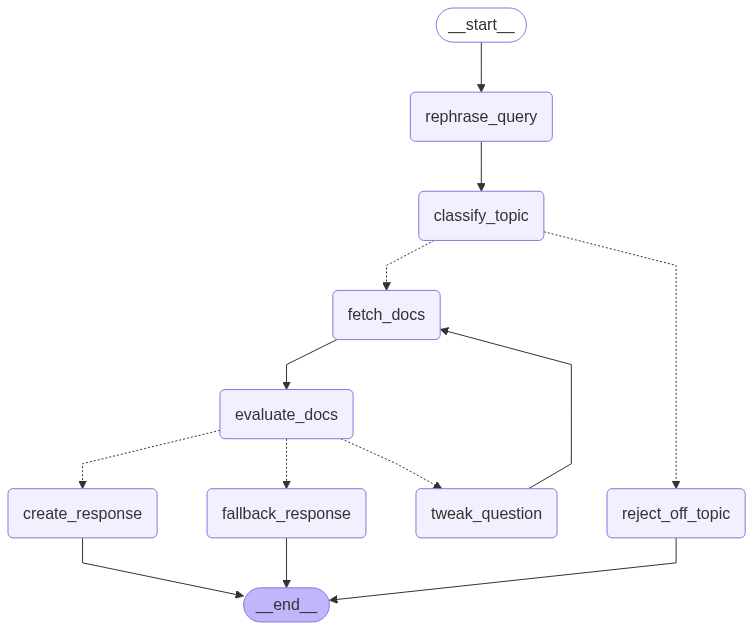

In [9]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [10]:
input_data = {"question": HumanMessage(content="How is the weather?")}
graph.invoke(input=input_data, config={"configurable": {"thread_id": 1}})

Entering rephrase_query with state: {'question': HumanMessage(content='How is the weather?', additional_kwargs={}, response_metadata={})}
Entering classify_topic
classify_topic: topic_flag = No
Entering topic_router
Routing to reject_off_topic
Entering reject_off_topic


{'turns': [HumanMessage(content='How is the weather?', additional_kwargs={}, response_metadata={}),
  AIMessage(content="I can't respond to that!", additional_kwargs={}, response_metadata={})],
 'retrieved_docs': [],
 'topic_flag': 'No',
 'refined_query': 'How is the weather?',
 'ready_for_response': False,
 'refinement_attempts': 0,
 'question': HumanMessage(content='How is the weather?', additional_kwargs={}, response_metadata={})}

In [11]:
input_data = {"question": HumanMessage(content="How old is the owner of the restaurant Bella Vista?")}
graph.invoke(input=input_data, config={"configurable": {"thread_id": 2}})

Entering rephrase_query with state: {'question': HumanMessage(content='How old is the owner of the restaurant Bella Vista?', additional_kwargs={}, response_metadata={})}
Entering classify_topic
classify_topic: topic_flag = Yes
Entering topic_router
Routing to fetch_docs
Entering fetch_docs
fetch_docs: Retrieved 2 documents
Entering evaluate_docs
Evaluating doc: Bella Vista is owned by Antoni... Result: No
Evaluating doc: Bella Vista is open from Monda... Result: No
evaluate_docs: ready_for_response = False
Entering decision_router
Routing to tweak_question
Entering tweak_question
tweak_question: Refined to: Revised question: What is the age of the owner of the Bella Vista restaurant?
Entering fetch_docs
fetch_docs: Retrieved 2 documents
Entering evaluate_docs
Evaluating doc: Bella Vista is owned by Antoni... Result: No
Evaluating doc: Bella Vista offers a range of ... Result: No
evaluate_docs: ready_for_response = False
Entering decision_router
Routing to tweak_question
Entering tweak_

{'turns': [HumanMessage(content='How old is the owner of the restaurant Bella Vista?', additional_kwargs={}, response_metadata={}),
  AIMessage(content="I'm sorry, but I couldn't find the information you're looking for.", additional_kwargs={}, response_metadata={})],
 'retrieved_docs': [],
 'topic_flag': 'Yes',
 'refined_query': 'Revised question: What is the age of the owner of Bella Vista restaurant?',
 'ready_for_response': False,
 'refinement_attempts': 2,
 'question': HumanMessage(content='How old is the owner of the restaurant Bella Vista?', additional_kwargs={}, response_metadata={})}

In [12]:
graph.invoke(input={"question": HumanMessage(content="When does Bella Vista open?")}, config={"configurable": {"thread_id": 3}})
graph.invoke(input={"question": HumanMessage(content="Also on Sunday?")}, config={"configurable": {"thread_id": 3}})

Entering rephrase_query with state: {'question': HumanMessage(content='When does Bella Vista open?', additional_kwargs={}, response_metadata={})}
Entering classify_topic
classify_topic: topic_flag = Yes
Entering topic_router
Routing to fetch_docs
Entering fetch_docs
fetch_docs: Retrieved 2 documents
Entering evaluate_docs
Evaluating doc: Bella Vista is open from Monda... Result: Yes
Evaluating doc: Bella Vista offers a range of ... Result: No
evaluate_docs: ready_for_response = True
Entering decision_router
Routing to create_response
Entering create_response
create_response: Answer generated: Bella Vista opens at 11:00 AM every day.
Entering rephrase_query with state: {'turns': [HumanMessage(content='When does Bella Vista open?', additional_kwargs={}, response_metadata={}), AIMessage(content='Bella Vista opens at 11:00 AM every day.', additional_kwargs={}, response_metadata={})], 'retrieved_docs': [Document(metadata={'source': 'restaurant_info.txt'}, page_content='Bella Vista is open f

{'turns': [HumanMessage(content='When does Bella Vista open?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Bella Vista opens at 11:00 AM every day.', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='Also on Sunday?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Yes, Bella Vista is open on Sundays.', additional_kwargs={}, response_metadata={})],
 'retrieved_docs': [Document(metadata={'source': 'restaurant_info.txt'}, page_content='Bella Vista is open from Monday to Sunday. Weekday hours are 11:00 AM to 10:00 PM, while weekend hours are extended from 11:00 AM to 11:00 PM.')],
 'topic_flag': 'Yes',
 'refined_query': 'AI: Is Bella Vista open on Sundays?',
 'ready_for_response': True,
 'refinement_attempts': 0,
 'question': HumanMessage(content='Also on Sunday?', additional_kwargs={}, response_metadata={})}